In [53]:
# Packages
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
import pygeoutils as geoutils
import pygeohydro as gh
import hydrofunctions as hf
from pygeohydro import WBD, NWIS
from pynhd import NLDI
import pandas as pd

from pynhd import GeoConnex

In [54]:
help(NWIS.get_info)

Help on function get_info in module pygeohydro.nwis:

get_info(self, queries: 'dict[str, str] | list[dict[str, str]]', expanded: 'bool' = False, fix_names: 'bool' = True) -> 'gpd.GeoDataFrame'
    Send multiple queries to USGS Site Web Service.
    
    Parameters
    ----------
    queries : dict or list of dict
        A single or a list of valid queries.
    expanded : bool, optional
        Whether to get expanded site information for example drainage area,
        default to False.
    fix_names : bool, optional
        If ``True``, reformat station names and some small annoyances,
        defaults to ``True``.
    
    Returns
    -------
    geopandas.GeoDataFrame
        A correctly typed ``GeoDataFrame`` containing site(s) information.



In [55]:
# Get basin boundary for s specific streamflow gauge
gauge_ID='08041780' # National Water Service streamflow gauge ID (USGS ID)
watershed_gauge = NLDI().get_basins([gauge_ID])
watershed_gauge.to_file(f'../data-processed/basin/watershed_gaugeID_{gauge_ID}.shp')

In [56]:
# Get the basin boundary for a specific HUC domain
HUC4 = '1202' # HUC4 ID
wbd = WBD("huc4")
Neches_HUC = wbd.byids("huc4", [HUC4])
Neches_HUC.to_file(f'../data-processed/basin/watershed_HUC4_{HUC4}.shp')

/var/folders/2f/3qcvb5n94gjgnh1b6hsrwxy09rfxld/T/ipykernel_27615/575400313.py:5: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  Neches_HUC.to_file(f'../data-processed/basin/watershed_HUC4_{HUC4}.shp')


In [57]:
# Get all the upstream gauges
nldi = NLDI()
# downstream gauge id
station_id = '08041780'

st_all = nldi.navigate_byid(
    fsource="nwissite",
    fid=f"USGS-{station_id}",
    navigation="upstreamTributaries",
    source="nwissite",
    distance=1000,
)

<Axes: >

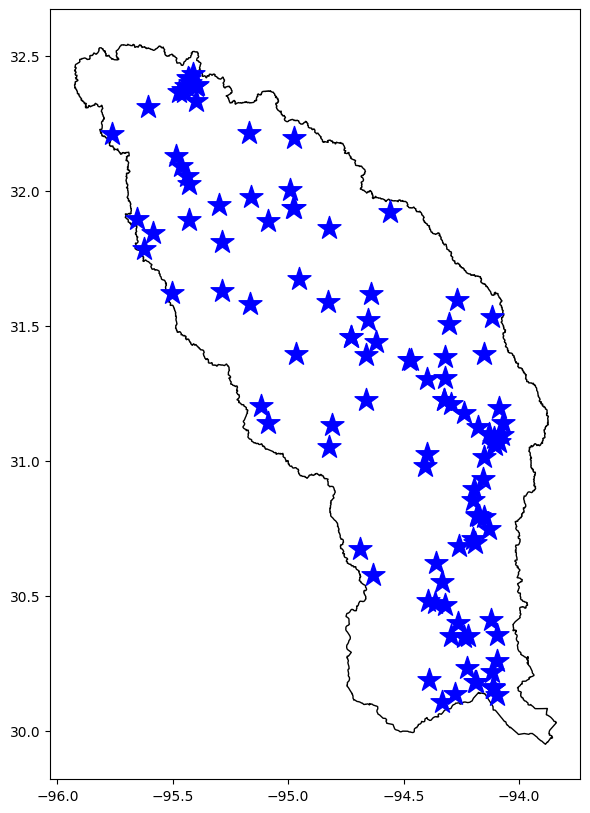

In [58]:
# Plot basin
fig, ax = plt.subplots(figsize=(10, 10))
Neches_HUC.plot(ax=ax, facecolor="none", edgecolor="black")
st_all.plot(ax=ax, label="USGS stations", marker="*", markersize=300, zorder=4, color="b")

In [59]:

# convert to tuple
bbox = tuple(np.array(Neches_HUC.bounds).flatten())



In [60]:
import xarray as xr
_ = xr.set_options(display_expand_attrs=False)
# bbox = (-69.5, 45, -69, 45.5)
bbox = tuple(np.array(Neches_HUC.bounds).flatten())
nwis_kwds = {"hasDataTypeCd": "iv", "outputDataTypeCd": "iv", "parameterCd": "00060"} # dv = daily value, iv = instantaneous value
gh.interactive_map(bbox, nwis_kwds=nwis_kwds)

In [61]:
# Get the data with more than 10 years of record
nwis = NWIS()
query = {
    "bBox": ",".join(f"{b:.06f}" for b in bbox),
    "hasDataTypeCd": "iv",
    "outputDataTypeCd": "iv",
}
info_box = nwis.get_info(query)
# clip the data with the basin boundary Neches_HUC
info_box_clipped = info_box.clip(Neches_HUC)

In [62]:
# filter the data for only gauges on streams (exclude lakes and canals)
info_box_clipped = info_box_clipped[info_box_clipped["site_tp_cd"] == "ST"]
info_box_clipped


,agency_cd,site_no,station_nm,site_tp_cd,dec_lat_va,dec_long_va,coord_acy_cd,dec_coord_datum_cd,alt_va,alt_acy_va,...,parm_grp_cd,srs_id,access_cd,begin_date,end_date,count_nu,nhd_id,nhd_areasqkm,hcdn_2009,geometry
132,USGS,08041790,"Neches Rv At Beaumont, TX",ST,30.094428,-94.090942,5,NAD83,0.00,0.1,...,,17164583,0,2020-05-04,2023-05-04,1095,<NA>,NaN,False,POINT (-94.09094 30.09443)
131,USGS,08041788,"Bairds Bayou At I-10 Nr Beaumont, TX",ST,30.095539,-94.076772,5,NAD83,0.00,0.1,...,,17164583,0,2020-05-03,2023-05-04,1096,<NA>,NaN,False,POINT (-94.07677 30.09554)
114,USGS,08041700,"Pine Island Bayou Nr Sour Lake, TX",ST,30.106046,-94.334632,F,NAD83,0.00,0.1,...,,1645423,0,2007-10-01,2023-05-04,5694,1143252,870.240,False,POINT (-94.33463 30.10605)
115,USGS,08041700,"Pine Island Bayou Nr Sour Lake, TX",ST,30.106046,-94.334632,F,NAD83,0.00,0.1,...,,17164583,0,2007-10-01,2023-05-04,5694,1143252,870.240,False,POINT (-94.33463 30.10605)
111,USGS,08041500,"Village Ck Nr Kountze, TX",ST,30.397986,-94.263521,F,NAD83,25.12,0.1,...,,1644459,0,2023-01-04,2023-05-04,120,1166409,2227.400,False,POINT (-94.26352 30.39799)
113,USGS,08041500,"Village Ck Nr Kountze, TX",ST,30.397986,-94.263521,F,NAD83,25.12,0.1,...,,17164583,0,2007-10-01,2023-05-04,5694,1166409,2227.400,False,POINT (-94.26352 30.39799)
112,USGS,08041500,"Village Ck Nr Kountze, TX",ST,30.397986,-94.263521,F,NAD83,25.12,0.1,...,,1645423,0,1990-10-01,2023-05-04,11903,1166409,2227.400,False,POINT (-94.26352 30.39799)
110,USGS,08041300,"Village Ck At Us Hwy 69 Nr Village Mills, TX",ST,30.481425,-94.394653,5,NAD83,0.00,0.1,...,,17164583,0,2018-06-13,2023-05-04,1786,<NA>,NaN,False,POINT (-94.39465 30.48143)
107,USGS,08041000,"Neches Rv At Evadale, TX",ST,30.355764,-94.093237,F,NAD83,8.25,0.1,...,,17164583,0,2007-10-01,2023-05-04,5694,1114207,20593.090,False,POINT (-94.09324 30.35576)
106,USGS,08041000,"Neches Rv At Evadale, TX",ST,30.355764,-94.093237,F,NAD83,8.25,0.1,...,,1645423,0,1990-10-01,2023-05-04,11903,1114207,20593.090,False,POINT (-94.09324 30.35576)


In [63]:
# Get data with at least 10 years 

Select = (info_box_clipped.end_date-info_box_clipped.begin_date)> pd.Timedelta("3650 days")
stations = info_box_clipped[
    Select
].site_no.tolist()

# Get the unique values of stations
stations = list(set(stations))

# filter the stations with at least 10 years of record
info_box_clipped = info_box_clipped[info_box_clipped.site_no.isin(stations)]

# Number of streamflow gauges
print(f'number of streamflow gauges with more than 10 years of record  = {len(stations)}')

number of streamflow gauges with more than 10 years of record  = 11


<Axes: >

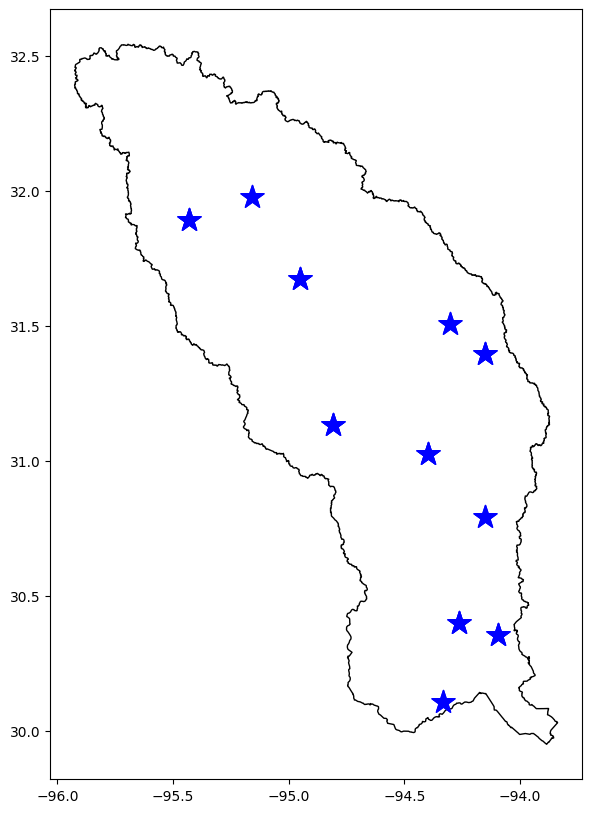

In [64]:
# plot data
fig, ax = plt.subplots(figsize=(10, 10))
Neches_HUC.plot(ax=ax, facecolor="none", edgecolor="black")
info_box_clipped.plot(ax=ax, label="USGS stations", marker="*", markersize=300, zorder=4, color="b")


In [65]:
# download the watershed basins, streamflow data, precipitation, and ET for each sub-basin

# Basin
for i in range(len(stations)):
    watershed_gauge = NLDI().get_basins(stations[i])
    watershed_gauge.to_file(f'../data-processed/basin/watershed_gaugeID_{stations[i]}.shp')
# watershed_gauge = NLDI().get_basins(stations[0])
# watershed_gauge.to_file(f'../data-processed/basin/watershed_gaugeID_{gauge_ID}.shp')


In [66]:

# export stations as a cvs file
# write cvs file
df = pd.DataFrame(stations, columns=['gauge_ID'])
df.to_csv('../data-processed/basin/List_gaugeID.csv')


In [67]:


# export info_box_clipped as a shapefile 
info_box_clipped.to_file('../data-processed/basin/gauges_Neches.shp')





/var/folders/2f/3qcvb5n94gjgnh1b6hsrwxy09rfxld/T/ipykernel_27615/2867351022.py:2: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  info_box_clipped.to_file('../data-processed/basin/gauges_Neches.shp')


TypeError: Cannot interpret 'Int32Dtype()' as a data type

In [ ]:
# streamflow
start_date = "2000-01-01 12:00"
end_date = "2020-31-12 12:00"
# qobs = nwis.get_streamflow(stations[0], ("1980-01-01", "2024-01-01"), freq="iv")
# Use hydrofunctions package
Q_obs =hf.NWIS(stations[0], 'iv', start_date='1900-01-01', end_date='2024-01-01', file=f'streamflow_{stations[0]}.gz')
Q_obs = Q_obs.df('discharge') # Hourly
Q_obs = Q_obs.dropna() 
Q_obs=Q_obs*0.0283168 # to m3/s

Q_obs.columns= ['Q [$m^3/s$]']
Q_obs['Time']=Q_obs.index.to_pydatetime()
Q_obs['Time'] = pd.to_datetime(Q_obs['Time']).dt.strftime('%Y-%m-%d-%H')
Q_obs_daily=Q_obs.resample("24H").mean()



In [ ]:
# precipitation
sid = stations[0]
coords = tuple(info[info.site_no == sid][["dec_long_va", "dec_lat_va"]].to_numpy()[0])
prcp = daymet.get_bycoords(coords, dates, variables="prcp", ssl=False)
qobs.index = pd.to_datetime(qobs.index.strftime("%Y-%m-%d"))


# ET

In [ ]:
# Get all the gauges within the watershed
gcx = GeoConnex(dev=False)
print("\n".join(f"{n}: {e.description}" for n, e in gcx.endpoints.items()))

In [ ]:
gcx.item = "hu04"
gcx

In [ ]:
h4 = gcx.byid("huc4", "1202")
ax = h4.plot(figsize=(6, 6))
ax.set_axis_off()

In [ ]:
gcx.item = "mainstems"
ms = gcx.bygeometry(h4.geometry.iloc[0], predicate="within", crs=h4.crs)
ax = h4.plot(figsize=(6, 6), facecolor="none", edgecolor="k")
ms.plot(ax=ax, color="b", lw=0.3)
ax.set_axis_off()

In [ ]:
gcx.item = "dams"
gcx

In [ ]:
dam = gcx.byid("nhdpv2_comid", ms.head_nhdpv2_comid)
ax = h4.plot(figsize=(6, 6), facecolor="none", edgecolor="k")
ms.plot(ax=ax, color="b", lw=0.3)
dam.plot(ax=ax, color="r", markersize=10, label="Dams")
ax.legend()
ax.set_axis_off()

In [ ]:
gcx.item = "gages"
gcx

In [ ]:
gcx.endpoints["gages"].dtypes

In [ ]:
outlet_ids = ms.loc[ms["head_nhdpv2_comid"].isin(dam["nhdpv2_comid"]), "outlet_nhdpv2_comid"]
comids = outlet_ids.str.rsplit("/", n=1).str[-1].astype(float)
gages = gcx.byid("nhdpv2_comid", comids)
ax = h4.plot(figsize=(6, 6), facecolor="none", edgecolor="k")
ms.plot(ax=ax, color="b", lw=0.3)
dam.plot(ax=ax, color="r", markersize=10, label="Dams")
gages.plot(ax=ax, color="g", markersize=10, marker="^", label="Gages")
ax.legend()
ax.set_axis_off()

In [ ]:
outlet_ids